In [ ]:
#-------------DATA CLEANING----------------

In [28]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
os.chdir("D:\\allstudymaterials\\MLprojects\\customer_click_prediction")

In [30]:
os.getcwd()

'D:\\allstudymaterials\\MLprojects\\customer_click_prediction'

In [31]:
df=pd.read_csv("advertising.csv")

In [32]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [34]:
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

In [35]:
df.shape

(1000, 10)

In [36]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [37]:
df['Hour']=df['Timestamp'].dt.hour

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Ad Topic Line             1000 non-null   object        
 5   City                      1000 non-null   object        
 6   Male                      1000 non-null   int64         
 7   Country                   1000 non-null   object        
 8   Timestamp                 1000 non-null   datetime64[ns]
 9   Clicked on Ad             1000 non-null   int64         
 10  Hour                      1000 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(3), object(3)
memory usage: 82.2+

In [39]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Hour
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,1
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,20
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,2
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,3


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad', 'Hour'],
      dtype='object')

In [42]:
#--------------------EDA--------------------------------------------

In [43]:
"""we will take continuous datas like (daily_time_spent, age, area_of_income, daily_internet_usage, time) and test these datas against categorical data clicked_on_add,
i.e. annova test"""

'we will take continuous datas like (daily_time_spent, age, area_of_income, daily_internet_usage, time) and test these datas against categorical data clicked_on_add,\ni.e. annova test'

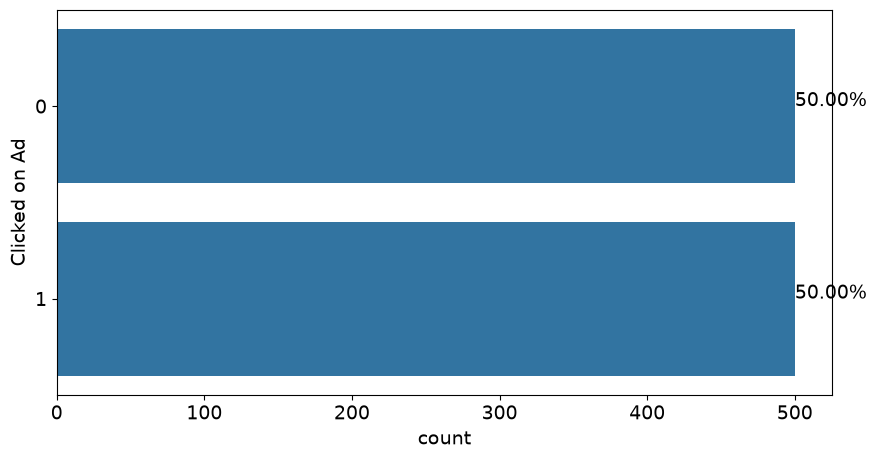

In [44]:
plt.figure(figsize=(10,5))
plt.rc("font", size=14)
ax = sns.countplot(y ='Clicked on Ad',data=df)
total = len(df['Clicked on Ad'])
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_width()/total)
    x = p.get_x() + p.get_width() + 0.02
    y = p.get_y() + p.get_height()/2
    ax.annotate(percentage, (x, y))
plt.rc("font", size=14)
plt.show()

In [47]:
# TargetVariable data here is perfectly balanced i.e. Clicked on Ad=1 is 50%  and Clicked on Ad=0 is 50% , so we dont need to SMOTE .

In [49]:
continuous_columns=['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage','Hour']   

In [ ]:
"""FEATURE SELECTION USING ANNOVA:"""

In [50]:
from scipy.stats import f_oneway

def FunctionAnova(inpData, TargetVariable, PredictorList):
    """
    Tests statistical relationship between continuous predictor variables 
    and a binary/categorical target variable using One-Way ANOVA.
    """
    SelectedPredictors = []

    print('##### ANOVA Results ##### \n')
    for predictor in PredictorList:
        # Group continuous predictor data by target categories
        CategoryGroupLists = inpData.groupby(TargetVariable)[predictor].apply(list)
        
        # Unpack groups into f_oneway
        stat, p_val = f_oneway(*CategoryGroupLists)

        # Check p-value threshold (alpha = 0.05)
        if p_val < 0.05:
            print(f"{predictor} is correlated with {TargetVariable} | P-Value: {p_val}")
            SelectedPredictors.append(predictor)
        else:
            print(f"{predictor} is NOT correlated with {TargetVariable} | P-Value: {p_val}")

    return SelectedPredictors

In [51]:
# Calling the function to check which continuousl variables are correlated with target(categorical)
FunctionAnova(inpData=df, TargetVariable="Clicked on Ad", PredictorList=continuous_columns)

##### ANOVA Results ##### 

Daily Time Spent on Site is correlated with Clicked on Ad | P-Value: 5.877384244139323e-180
Age is correlated with Clicked on Ad | P-Value: 3.1298083092905155e-62
Area Income is correlated with Clicked on Ad | P-Value: 9.44958341282883e-58
Daily Internet Usage is correlated with Clicked on Ad | P-Value: 3.893234122539366e-211
Hour is NOT correlated with Clicked on Ad | P-Value: 0.1339077477423824


['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

In [ ]:
# so, DailyTimeSpent,Age,AreaIncome,DailyInternetUsage are corealated.

In [ ]:
FEATURE SELECTION WITH CHI-SQUARE:

now we will check if the rest of the columns(Ad_Topic_Line,Country,Male) which are all categorical data are anyway related to the target column 
Clicked_on_adds which is also a categorical data. so we will go for chi-square test:

In [52]:
# Writing a function to find the correlation of all categorical variables with the Target variable
def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### chi-square Results ##### \n')
    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)

        # If the ChiSq P-Value is <0.05, that means we reject H0, -> p low, null go
        if ( ChiSqResult[1] < 0.05 ):
            SelectedPredictors.append(predictor)
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    return(SelectedPredictors)

In [53]:
categorical_columns=['Ad Topic Line', 'City', 'Country','Male'] 

In [54]:
FunctionChisq(inpData=df,TargetVariable="Clicked on Ad",CategoricalVariablesList= categorical_columns)

##### chi-square Results ##### 

Ad Topic Line is NOT correlated with Clicked on Ad | P-Value: 0.48513148927490146
City is NOT correlated with Clicked on Ad | P-Value: 0.43395559179296606
Country is NOT correlated with Clicked on Ad | P-Value: 0.7737565395501936
Male is NOT correlated with Clicked on Ad | P-Value: 0.2546019035670961


[]

In [ ]:
So these are not correlated, Now we will use logistic regression with variables ('Daily Time Spent on Site', 'Age', 'Area Income',
'Daily Internet Usage') on 'target variable Clicked on Ad'.

In [ ]:
LABELLING AND SCALING >>>

we dont need any labelling techniques here cause the data are continuous in nature. Instead we will use
Standard Scaling(recommended for logistic regression) before proceeding with logistic regression.

If data is normally distributed we would use StandardScalar, if features are heavily skewed we use MinMaxScaler.

Now we will check how data is distributed, using vizualization.

    

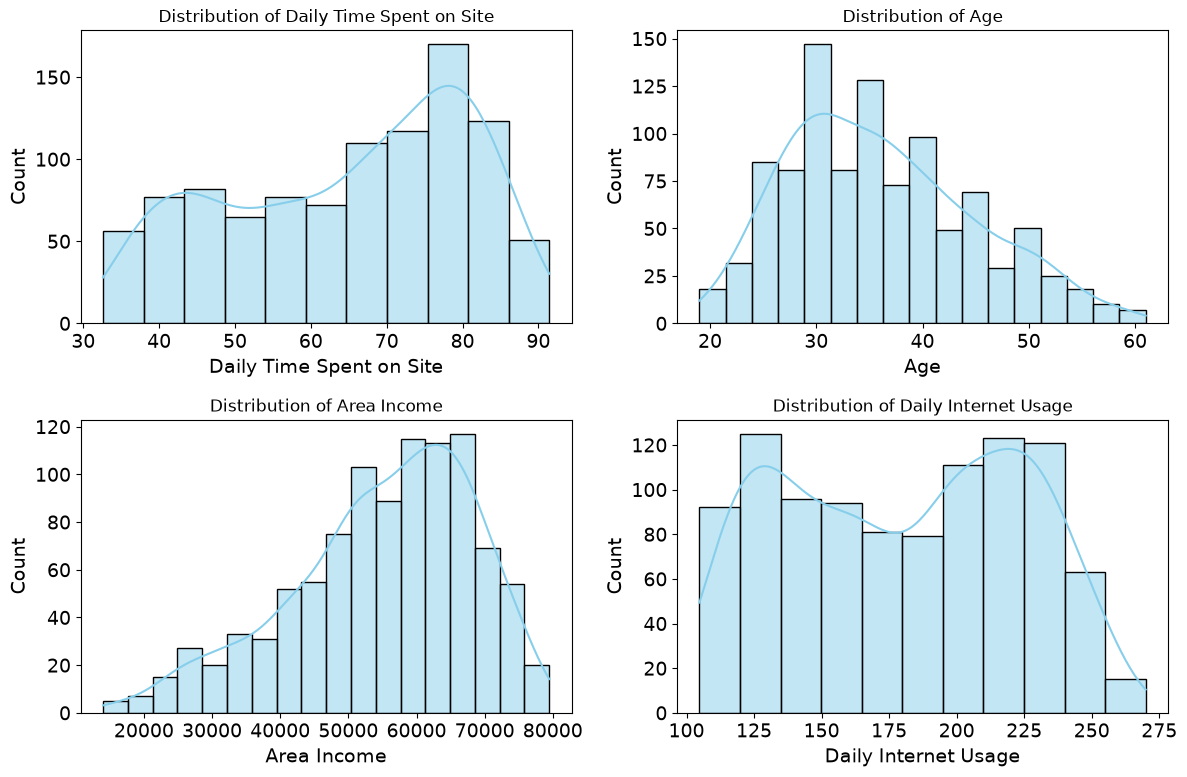

In [55]:
"""first we need to see if the data for all variable in continuous columns are uniformly distributed ."""
import matplotlib.pyplot as plt
import seaborn as sns
# Define continuous predictor columns
continuous_columns = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

# Set up a grid of subplots (2 rows, 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()  # Flatten to easily iterate with a single loop

# Loop through columns and plot histograms with KDE curves
for i, col in enumerate(continuous_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
The data is skewed for all columns, we could use minmax scalar but its highly sensitive to extreme outliers,
since we are using logistic regression, we can still use standardscalar in practice, its solid choice here.

In [ ]:
NOW we will go for scaling and then regression and then accuracy:

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Prepare features (X) and target (y)
X = df[continuous_columns]  # Include any encoded categorical features here as well
y = df['Clicked on Ad']     # Update target column name if different

# 2. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale continuous features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate the model
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9500

Confusion Matrix:
[[ 86   3]
 [  7 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        89
           1       0.97      0.94      0.95       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

